In [25]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_colwidth', None)  # Display full content of each column
pd.set_option('display.max_columns', None)   # Display all columns
pd.set_option('display.width', 5000)         # Set display width

In [26]:
# df1 = pd.read_csv(r'C:\Users\yashs\Desktop\Journey\SpendWise\ml_service\clean_sms_eda.csv')

df = pd.read_csv(r'C:\Users\yashs\Desktop\Journey\SpendWise\ml_service\true_financial_sms.csv')



In [27]:
print(df.shape)
df1.shape

(168, 15)


(3100, 15)

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the true financial data
df = pd.read_csv(r'C:\Users\yashs\Desktop\Journey\SpendWise\ml_service\true_financial_sms.csv')

# Convert dates to datetime objects for easy time-series analysis
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')
df['day_name'] = df['date'].dt.day_name()

print(f"Successfully loaded {len(df)} financial transactions!")


Successfully loaded 168 financial transactions!


💰 OVERALL FINANCIAL SUMMARY
Total Transactions: 168
Total Money In (Credit): ₹226,217.00
Total Money Out (Debit): ₹312,142.16
Net Cash Flow: ₹-85,925.16


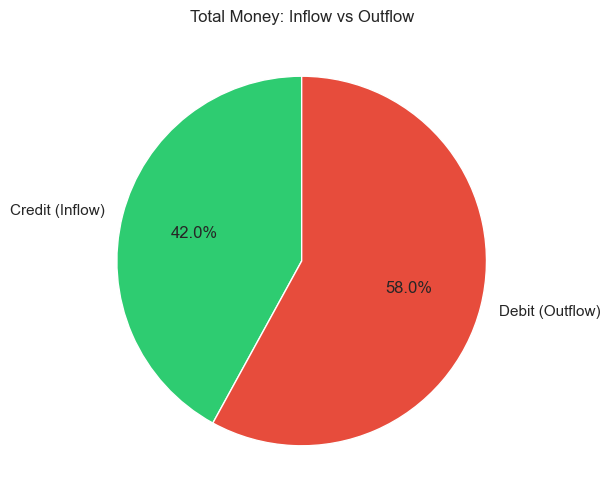

In [29]:
# Separate into credits and debits
credits_df = df[df['direction'] == 'CREDIT']
debits_df = df[df['direction'] == 'DEBIT']

total_credit = credits_df['amount'].sum()
total_debit = debits_df['amount'].sum()
net_flow = total_credit - total_debit

print("="*40)
print("💰 OVERALL FINANCIAL SUMMARY")
print("="*40)
print(f"Total Transactions: {len(df)}")
print(f"Total Money In (Credit): ₹{total_credit:,.2f}")
print(f"Total Money Out (Debit): ₹{total_debit:,.2f}")
print(f"Net Cash Flow: ₹{net_flow:,.2f}")
print("="*40)

# Quick pie chart
plt.pie([total_credit, total_debit], labels=['Credit (Inflow)', 'Debit (Outflow)'], 
        autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
plt.title('Total Money: Inflow vs Outflow')
plt.show()


You received money 46 times.
You spent money 122 times.
Average Credit Amount: ₹4,917.76
Average Debit Amount: ₹2,558.54


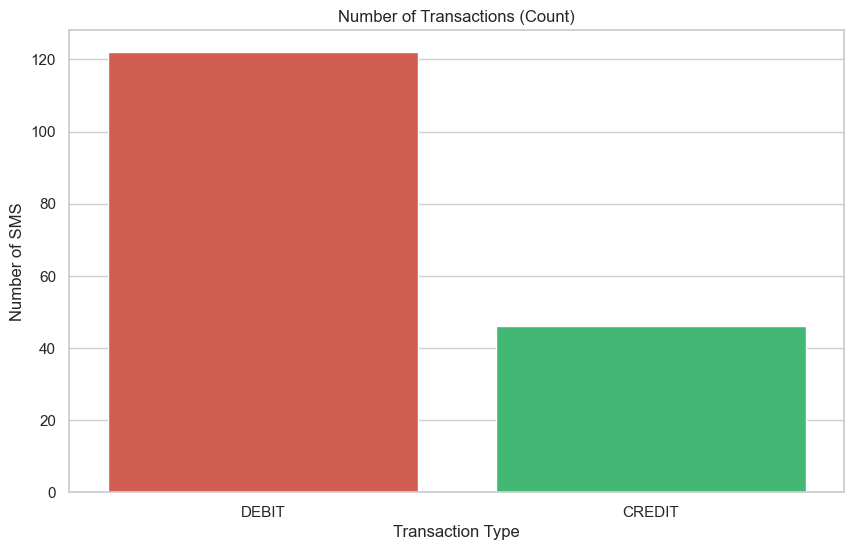

In [30]:
credit_count = len(credits_df)
debit_count = len(debits_df)

print(f"You received money {credit_count} times.")
print(f"You spent money {debit_count} times.")

if credit_count > 0:
    print(f"Average Credit Amount: ₹{total_credit/credit_count:,.2f}")
if debit_count > 0:
    print(f"Average Debit Amount: ₹{total_debit/debit_count:,.2f}")

# Plot frequency of transactions
sns.countplot(data=df, x='direction', palette={'CREDIT': '#2ecc71', 'DEBIT': '#e74c3c'})
plt.title('Number of Transactions (Count)')
plt.ylabel('Number of SMS')
plt.xlabel('Transaction Type')
plt.show()


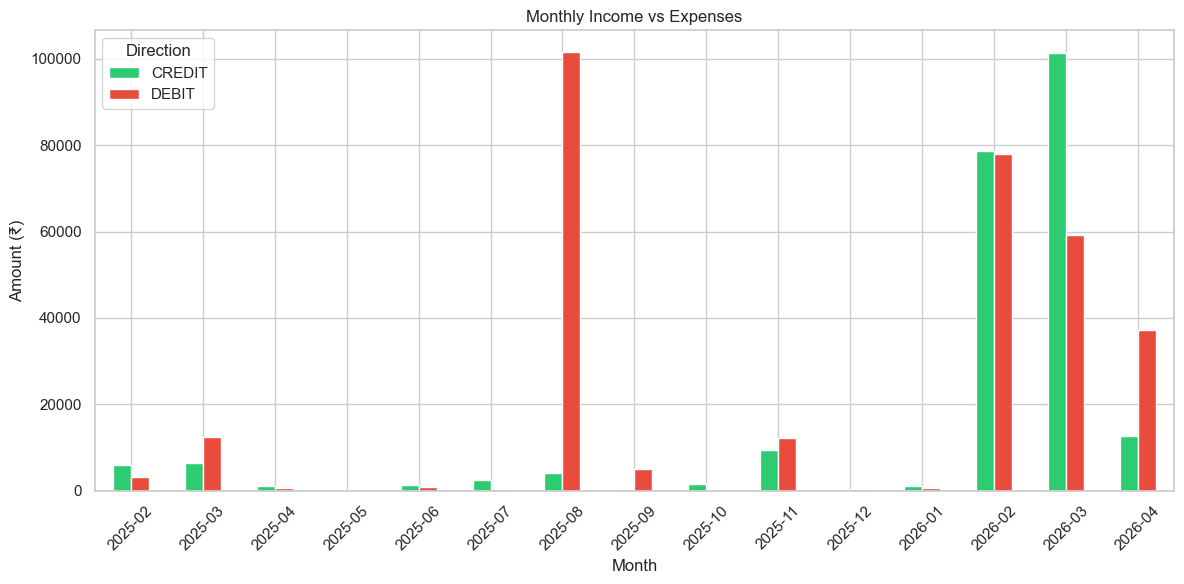

direction,CREDIT,DEBIT,Net Flow
month,,,
2025-02,"₹6,000.00","₹3,293.96","₹2,706.04"
2025-03,"₹6,389.00","₹12,485.82","₹-6,096.82"
2025-04,"₹1,000.00",₹637.00,₹363.00
2025-05,₹0.00,₹133.96,₹-133.96
2025-06,"₹1,400.00",₹909.00,₹491.00
2025-07,"₹2,530.00",₹439.00,"₹2,091.00"
2025-08,"₹4,200.00","₹101,479.00","₹-97,279.00"
2025-09,₹300.00,"₹5,084.00","₹-4,784.00"
2025-10,"₹1,500.00",₹60.00,"₹1,440.00"


In [31]:
# Group by month and direction to get sums
monthly_stats = df.groupby(['month', 'direction'])['amount'].sum().unstack(fill_value=0)

# Ensure columns exist just in case
if 'CREDIT' not in monthly_stats.columns: monthly_stats['CREDIT'] = 0
if 'DEBIT' not in monthly_stats.columns: monthly_stats['DEBIT'] = 0

# Plotting monthly trends
monthly_stats.plot(kind='bar', color={'CREDIT': '#2ecc71', 'DEBIT': '#e74c3c'}, figsize=(12, 6))
plt.title('Monthly Income vs Expenses')
plt.ylabel('Amount (₹)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.legend(title='Direction')
plt.tight_layout()
plt.show()

# Show raw data
monthly_stats['Net Flow'] = monthly_stats['CREDIT'] - monthly_stats['DEBIT']
display(monthly_stats.style.format("₹{:,.2f}"))


📉 Top 10 Largest Spending Categories / Entities:


,amount
entity_clean,
NAN,"₹281,449.22"
ABHIJIT KISHOR K,"₹11,200.00"
MR VIHAAN SACHIN,"₹2,170.00"
DREAM LAND BAR,"₹2,089.00"
BLOWDOWS TRADEMA,"₹1,500.00"
PRATHAM SURENDRA,"₹1,231.20"
ORIEN SALES,"₹1,150.00"
AIRTEL,₹897.00
NYRAA ECOMMERCE,₹890.00


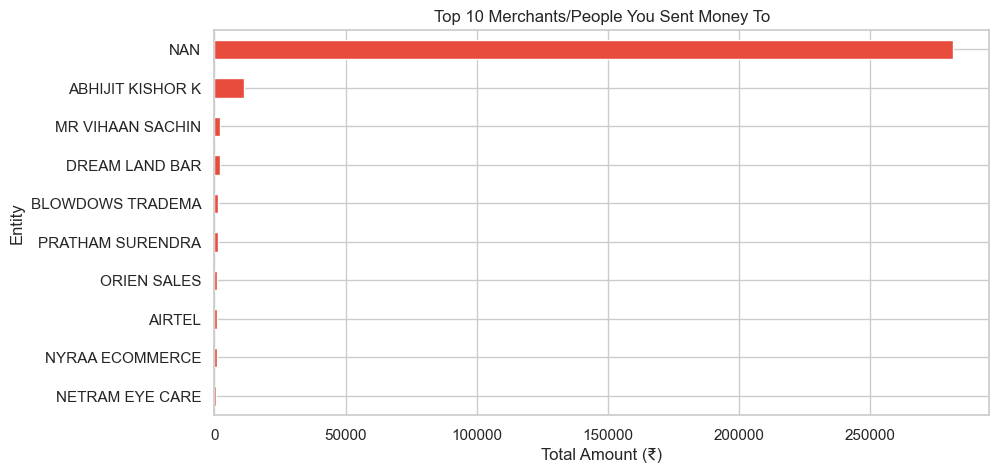


📈 Top 10 Largest Income Sources:


,amount
entity_clean,
NAN,"₹205,720.00"
NEHA NITIN KADAM,"₹5,000.00"
RUCHA NITIN KADAM,"₹5,000.00"
PRACHI SAMEER SAWANT,"₹3,900.00"
SHUBHAM HEMANT RAJAPURKAR,"₹1,999.00"
ASIM HEMAL SHAH,"₹1,000.00"
ATHARV VIKAS KHABALE,"₹1,000.00"
MAYANK RAMJI RAVARIA,"₹1,000.00"
NINAD SACHIN MAADHAVI,"₹1,000.00"


In [34]:
# 1. Clean the entity column to group similar names together on the MAIN dataframe
df['entity_clean'] = df['entity'].astype(str).str.upper().str.strip()

# 2. Re-create the Credit and Debit dataframes so they include the new column
credits_df = df[df['direction'] == 'CREDIT']
debits_df = df[df['direction'] == 'DEBIT']

# 3. Top 10 Places you SPEND money
top_merchants = debits_df.groupby('entity_clean')['amount'].sum().sort_values(ascending=False).head(10)
print("📉 Top 10 Largest Spending Categories / Entities:")
display(pd.DataFrame(top_merchants).style.format("₹{:,.2f}"))

# 4. Plot top merchants
plt.figure(figsize=(10, 5))
top_merchants.plot(kind='barh', color='#e74c3c').invert_yaxis()
plt.title('Top 10 Merchants/People You Sent Money To')
plt.xlabel('Total Amount (₹)')
plt.ylabel('Entity')
plt.show()

# 5. Top 10 Sources of INCOME
top_sources = credits_df.groupby('entity_clean')['amount'].sum().sort_values(ascending=False).head(10)
print("\n📈 Top 10 Largest Income Sources:")
display(pd.DataFrame(top_sources).style.format("₹{:,.2f}"))
